# Comment démasquer les fraudeurs ? BNP Paribas PF
Sujet du projet : <href>https://challengedata.ens.fr</href>

## Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from lazypredict.Supervised import LazyClassifier
from pandas import wide_to_long
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import auc
from sklearn.metrics import average_precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.utils import resample
from tqdm.auto import tqdm
from xgboost import plot_importance
from xgboost import XGBClassifier

from bnp_paribas_fraud_detection_preprocessing import map_item_group
from bnp_paribas_fraud_detection_preprocessing import map_model_group
from bnp_paribas_fraud_detection_preprocessing import simplify_make

tqdm.pandas()

## Chargement des données

In [ ]:
X_train = pd.read_csv("X_train_G3tdtEn.csv")
y_train = pd.read_csv("Y_train_2_XPXJDyy.csv")
X_test = pd.read_csv("X_test_8skS2ey.csv")
y_test = pd.read_csv("Y_test_random_2.csv")

/var/folders/0h/_q4yqym170z4tlrrc27fq1vm0000gn/T/ipykernel_29918/364139321.py:8: DtypeWarning: Columns (21,22,23,24,69,70,71,72,93,94,95,96,97,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train = pd.read_csv("X_train_G3tdtEn.csv")
/var/folders/0h/_q4yqym170z4tlrrc27fq1vm0000gn/T/ipykernel_29918/364139321.py:10: DtypeWarning: Columns (20,21,22,23,24,68,69,70,71,72,92,93,94,95,96,97,106,107,108,109,110,111,112,113,114,115,116,117,118) have mixed types. Specify dtype option on import or set low_memory=False.
  X_test = pd.read_csv("X_test_8skS2ey.csv")


## Preprocessing

In [ ]:
# Jointure pour associer le bon fraud_flag à chaque ID
train_full = X_train.merge(
    y_train[["ID", "fraud_flag"]],
    on="ID",
    how="left"
)

test_full = X_test.merge(
    y_test[["ID", "fraud_flag"]],
    on="ID",
    how="left"
)

# Passage wide -> long
cols_article = [
    "item",
    "cash_price",
    "make",
    "model",
    "goods_code",
    "Nbr_of_prod_purchas"
]

train_long = wide_to_long(
    train_full,
    stubnames=cols_article,
    i="ID",          # identifiant de la transaction
    j="position",    # indice 1..24
    sep="",          # item1, item2, ...
    suffix="\\d+"
).reset_index()

test_long = wide_to_long(
    test_full,
    stubnames=cols_article,
    i="ID",
    j="position",
    sep="",
    suffix="\\d+"
).reset_index()

# Suppression des lignes de position TOTALEMENT vides
train_long = train_long.dropna(subset=cols_article, how="all") 
train_long = train_long.drop(columns=["position", "goods_code"])
test_long = test_long.dropna(subset=cols_article, how="all")
test_long = test_long.drop(columns=["position", "goods_code"])


BRANDS = [
    "APPLE","SAMSUNG","SONY","LG","HP","DELL","LENOVO","ASUS","ACER",
    "MICROSOFT","GOOGLE","NINTENDO","BOSE","PANASONIC","TOSHIBA",
    "LOGITECH","TARGUS","DYSON","NESPRESSO","NINJA","PHILIPS","HUAWEI",
    "RING","ARLO","EPSON","BROTHER","CANON","NIKON"
]


# Calculer les top 50 marques
make_counts = train_long["make"].value_counts()
top_makes = set(make_counts.head(50).index)

In [ ]:
# APPLICATION DES MAPPINGS

train_long["item_group"] = train_long["item"].progress_apply(map_item_group)
train_long["model_group"] = train_long["model"].progress_apply(map_model_group)
train_long["brand_group"] = train_long["make"].progress_apply(lambda x: simplify_make(x, top_makes))
train_long.drop(columns=['item'], inplace=True)
train_long.drop(columns=['model'], inplace=True)
train_long.drop(columns=['make'], inplace=True)

test_long["item_group"] = test_long["item"].progress_apply(map_item_group)
test_long["model_group"] = test_long["model"].progress_apply(map_model_group)
test_long["brand_group"] = test_long["make"].progress_apply(lambda x: simplify_make(x, top_makes))
test_long.drop(columns=['item'], inplace=True)
test_long.drop(columns=['model'], inplace=True)
test_long.drop(columns=['make'], inplace=True)

  0%|          | 0/163357 [00:00<?, ?it/s]

  0%|          | 0/163357 [00:00<?, ?it/s]

  0%|          | 0/163357 [00:00<?, ?it/s]

  0%|          | 0/41042 [00:00<?, ?it/s]

  0%|          | 0/41042 [00:00<?, ?it/s]

  0%|          | 0/41042 [00:00<?, ?it/s]

In [39]:
y_train_long = train_long[["ID", "fraud_flag"]].set_index("ID")
y_test_long = test_long[["ID", "fraud_flag"]].set_index("ID")

X_train_long = train_long.drop(columns=["fraud_flag"]).set_index("ID")
X_test_long = test_long.drop(columns=["fraud_flag"]).set_index("ID")

In [40]:
X_train_long.shape, y_train_long.shape, X_test_long.shape, y_test_long.shape

((163357, 6), (163357, 1), (41042, 6), (41042, 1))

In [41]:
X_train_long.head()

,Nb_of_items,cash_price,Nbr_of_prod_purchas,item_group,model_group,brand_group
ID,,,,,,
85517,1.00,889.00,1.00,TECH & COMPUTING,COMPUTER,APPLE
51113,1.00,409.00,1.00,TECH & COMPUTING,WEARABLE,APPLE
83008,1.00,1399.00,1.00,TV AUDIO VIDEO,TV_AUDIO_VIDEO,SAMSUNG
78712,2.00,689.00,1.00,TECH & COMPUTING,TABLET,APPLE
77846,1.00,1199.00,1.00,TV AUDIO VIDEO,TV_AUDIO_VIDEO,SONY


## Machine Learning

In [ ]:
categorical_cols = X_train_long.select_dtypes(include=["object"]).columns.tolist() # Colonnes catégorielles = dtype object

numeric_cols = X_train_long.columns.difference(categorical_cols).tolist() # Colonnes numériques = tout le reste

print("Catégorielles :", len(categorical_cols))
print("Numériques    :", len(numeric_cols))


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"  # on ne garde que ces colonnes
)

Catégorielles : 3
Numériques    : 3


### PCA

In [ ]:
pca = PCA(random_state=42, n_components=6)

pipe_pca = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("pca", pca),
])

pipe_pca.fit(X_train_long[y_train_long["fraud_flag"] == 0])

X_train_pca = pipe_pca.transform(X_train_long)
X_test_pca = pipe_pca.transform(X_test_long)

print("Shape train après ACP :", X_train_pca.shape)
print("Shape test après ACP :", X_test_pca.shape)
print("Variance expliquée cumulée :", pipe_pca.named_steps["pca"].explained_variance_ratio_.cumsum())

df_pca_train = pd.DataFrame(X_train_pca, columns=[f"PC{i+1}" for i in range(X_train_pca.shape[1])])
df_pca_test  = pd.DataFrame(X_test_pca,  columns=[f"PC{i+1}" for i in range(X_test_pca.shape[1])])

Shape train après ACP : (163357, 6)
Shape test après ACP : (41042, 6)
Variance expliquée cumulée : [0.57297376 0.72221271 0.79924893 0.83875555 0.86893839 0.89175331]


In [44]:
X_train_pca.shape, y_train_long.shape, X_test_pca.shape, y_test_long.shape

((163357, 6), (163357, 1), (41042, 6), (41042, 1))

### LazyClassifier

In [ ]:
# On prend un sous-échantillon stratifié (pour garder la proportion de fraude)
X_sub, y_sub = resample(X_train_pca, y_train_long["fraud_flag"], 
                        n_samples=30000, 
                        stratify=y_train_long["fraud_flag"], 
                        random_state=42)

clf_lazy = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=roc_auc_score, predictions=True)

# Lancement sur l'échantillon réduit
models, predictions = clf_lazy.fit(X_sub, X_test_pca, y_sub, y_test_long["fraud_flag"] >= 0.4)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 426, number of negative: 29574
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000386 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 30000, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014200 -> initscore=-4.240212
[LightGBM] [Info] Start training from score -4.240212


In [46]:
print(models)

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
PassiveAggressiveClassifier        0.45               0.50     0.50      0.41   
NearestCentroid                    0.49               0.50     0.50      0.49   
ExtraTreeClassifier                0.40               0.50     0.50      0.23   
RandomForestClassifier             0.40               0.50     0.50      0.23   
DecisionTreeClassifier             0.40               0.50     0.50      0.23   
ExtraTreesClassifier               0.40               0.50     0.50      0.23   
LabelPropagation                   0.40               0.50     0.50      0.23   
XGBClassifier                      0.40               0.50     0.50      0.23   
LabelSpreading                     0.40               0.50     0.50      0.23   
KNeighborsClassifier               0.40               0.50     0.50      0.23   
LGBMClassifier              

In [ ]:
# 1. On se concentre UNIQUEMENT sur les données d'entraînement (Train)
X = X_train_pca
y = y_train_long["fraud_flag"]

# 2. On crée notre propre "Test Set" fiable à partir du Train
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  # Indispensable pour garder la même proportion de fraude
)

print(f"Train shape: {X_train_split.shape}")
print(f"Validation shape: {X_val_split.shape}")

# 3. On réduit le TRAIN à 10 000 lignes pour que les algos lourds (SVM, etc.) passent
# On garde le stratify pour conserver la proportion de fraude
X_train_small, y_train_small = resample(
    X_train_split, 
    y_train_split, 
    n_samples=10000,      # Suffisant pour comparer les algos
    stratify=y_train_split, 
    random_state=42
)

# 4. On garde la VALIDATION complète (49k) pour avoir un score fiable
print(f"Train (small): {X_train_small.shape}")
print(f"Validation: {X_val_split.shape}")

# 5. Lancement
clf = LazyClassifier(
    verbose=0, 
    ignore_warnings=True, 
    custom_metric=roc_auc_score
)

models, predictions = clf.fit(X_train_small, X_val_split, y_train_small, y_val_split)
print(models)

Train shape: (114349, 6)
Validation shape: (49008, 6)
Train (small): (10000, 6)
Validation: (49008, 6)


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 142, number of negative: 9858
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.014200 -> initscore=-4.240212
[LightGBM] [Info] Start training from score -4.240212
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
NearestCentroid                    0.65               0.60     0.60      0.77   
ExtraTreeClassifier                0.98               0.52     0.52      0.98   
DecisionTreeClassifier             0.98               0.51     0.51      0.98   
RandomForestClassifier             0.98               0.51     0.51      0.98   
ExtraTreesClassifier    

### RandomForest

In [ ]:
print("--- Random Forest Balanced ---")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,            # On limite la profondeur pour éviter le sur-apprentissage
    class_weight='balanced', # <--- LA CLÉ : Pénalise fortement les erreurs sur la fraude
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_split, y_train_split) # Utilisez le SPLIT complet (114k lignes) ça passera en RAM
y_pred_rf = rf.predict(X_val_split)
y_proba_rf = rf.predict_proba(X_val_split)[:, 1]

print("AUC ROC:", roc_auc_score(y_val_split, y_proba_rf))
print("AUPRC (Precision-Recall):", average_precision_score(y_val_split, y_proba_rf))
print(classification_report(y_val_split, y_pred_rf))

--- Random Forest Balanced ---
AUC ROC: 0.80212418809183
AUPRC (Precision-Recall): 0.07078484214329334
              precision    recall  f1-score   support

           0       0.99      0.73      0.84     48313
           1       0.04      0.73      0.07       695

    accuracy                           0.73     49008
   macro avg       0.52      0.73      0.46     49008
weighted avg       0.98      0.73      0.83     49008



### XGBoost

In [ ]:
print("\n--- XGBoost Weighted ---")
# Calcul du ratio pour scale_pos_weight
ratio = (y_train_split == 0).sum() / (y_train_split == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=np.sqrt(ratio),  # <--- LA CLÉ pour XGBoost : sqrt(ratio) est souvent un bon compromis
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_split, y_train_split)
y_proba_xgb = xgb.predict_proba(X_val_split)[:, 1]

print("AUC ROC:", roc_auc_score(y_val_split, y_proba_xgb))
print("AUPRC:", average_precision_score(y_val_split, y_proba_xgb))


--- XGBoost Weighted ---
AUC ROC: 0.8127483449872065
AUPRC: 0.10105594246581821


In [ ]:
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.98] # On teste plusieurs seuils pour voir l'impact

print(f"{'Seuil':<10} {'Précision':<10} {'Rappel':<10} {'F1-Score':<10}")
for thresh in thresholds:
    y_pred_thresh = (y_proba_xgb > thresh).astype(int)
    p = precision_score(y_val_split, y_pred_thresh)
    r = recall_score(y_val_split, y_pred_thresh)
    f1 = f1_score(y_val_split, y_pred_thresh)
    print(f"{thresh:<10} {p:.4f}     {r:.4f}     {f1:.4f}")

Seuil      Précision  Rappel     F1-Score  
0.5        0.2216     0.1151     0.1515
0.6        0.2416     0.1036     0.1450
0.7        0.3733     0.0403     0.0727
0.8        0.8571     0.0086     0.0171
0.9        1.0000     0.0014     0.0029
0.95       0.0000     0.0000     0.0000
0.98       0.0000     0.0000     0.0000


#### XGBoost non basé sur l'ACP

In [51]:
X_train_ready = X_train_long.copy()
X_test_ready = X_test_long.copy()

# 1. Identifier les colonnes de texte (catégorielles)
cat_cols = X_train_ready.select_dtypes(include=['object', 'category']).columns
print(f"Colonnes catégorielles détectées : {list(cat_cols)}")

# 2. Encoder les textes en chiffres (Label Encoding simple)
# C'est suffisant pour les modèles à base d'arbres comme XGBoost
for col in cat_cols:
    # On force le type 'category' puis on récupère les codes numériques
    X_train_ready[col] = X_train_ready[col].astype('category').cat.codes
    X_test_ready[col] = X_test_ready[col].astype('category').cat.codes

# 3. Retirer la colonne ID (si elle est présente dans X)
if 'ID' in X_train_ready.columns:
    train_ids = X_train_ready['ID']
    X_train_ml = X_train_ready.drop(columns=['ID'])
else:
    X_train_ml = X_train_ready

if 'ID' in X_test_ready.columns:
    X_test_ml = X_test_ready.drop(columns=['ID'])
    # On garde les IDs de côté pour la soumission finale
    test_ids = X_test_ready['ID']
else:
    X_test_ml = X_test_ready
    # Si l'ID n'est pas dans X, assurez-vous de l'avoir ailleurs pour la soumission !
    # test_ids = test_long['ID']

Colonnes catégorielles détectées : ['item_group', 'model_group', 'brand_group']


In [53]:
# 1. Calcul du ratio pour gérer le déséquilibre
target = y_train_long["fraud_flag"] if isinstance(y_train_long, pd.DataFrame) else y_train_long

num_neg = (target == 0).sum()
num_pos = (target == 1).sum()
ratio = num_neg / num_pos
print(f"Ratio utilisé : {ratio:.2f}")

# 2. Configuration du XGBoost (Version optimisée)
xgb_full = XGBClassifier(
    n_estimators=300,        # Nombre d'arbres
    max_depth=8,             # Un peu plus profond car plus de variables (avant PCA on était à 6)
    learning_rate=0.1,
    scale_pos_weight=np.sqrt(ratio),  # LA CLÉ pour la fraude
    subsample=0.8,           # Pour éviter le sur-apprentissage
    colsample_bytree=0.8,    # Idem
    random_state=42,
    n_jobs=-1
)

# 3. Entraînement
print("Entraînement en cours sur les données COMPLÈTES (sans PCA)...")
xgb_full.fit(X_train_ml, target)

Ratio utilisé : 69.50
Entraînement en cours sur les données COMPLÈTES (sans PCA)...


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [54]:
# 0. Prédire les probabilités
probs_test = xgb_full.predict_proba(X_test_ml)[:, 1]

# 1. On recharge le fichier Test original pour avoir les VRAIS IDs
X_test_raw = pd.read_csv("X_test_8skS2ey.csv")

# 2. On recrée la structure exacte qui a servi à faire les prédictions
# (C'est indispensable pour que la ligne 1 de prédiction tombe en face du bon ID)
cols_article = ["item", "cash_price", "make", "model", "goods_code", "Nbr_of_prod_purchas"]

# Transformation identique à votre preprocessing
X_test_struct = wide_to_long(
    X_test_raw,
    stubnames=cols_article,
    i="ID",
    j="position",
    sep="",
    suffix=r"\d+"
).reset_index() # Ici on récupère "ID" et "position" comme colonnes

# Filtre identique (suppression des items vides)
X_test_struct = X_test_struct.dropna(subset=cols_article, how="all")

# 3. Vérification de sécurité
print(f"Nombre de prédictions en mémoire : {len(probs_test)}")
print(f"Nombre de lignes recréées      : {len(X_test_struct)}")

if len(probs_test) == len(X_test_struct):
    # 4. Création du DataFrame final
    df_pred = pd.DataFrame({
        "ID": X_test_struct["ID"].values,  # On prend les valeurs de la colonne ID explicite
        "fraud_prob": probs_test
    })

    # 5. Agrégation par ID (Max Pooling)
    # Si un article est frauduleux, la commande l'est -> on garde le max
    submission = df_pred.groupby("ID")["fraud_prob"].max().reset_index()
    submission.columns = ["ID", "fraud_flag"]

    # 6. Sauvegarde
    filename = "Soumission_Finale_XGB_Corrigee.csv"
    submission.to_csv(filename, index=False)
    
    print(f"\nSUCCÈS : Fichier '{filename}' généré !")
    print("Aperçu des IDs :") # IDs triés par groupby, donc pas forcément dans l'ordre de X_test_struct
    print(submission.head())
else:
    print("\nERREUR D'ALIGNEMENT")
    print("Le nombre de lignes ne correspond pas. Avez-vous appliqué un autre filtre sur X_test_ml ?")

Nombre de prédictions en mémoire : 41042
Nombre de lignes recréées      : 41042

SUCCÈS : Fichier 'Soumission_Finale_XGB_Corrigee.csv' généré !
Aperçu des IDs :
   ID  fraud_flag
0   3        0.18
1   6        0.06
2   9        0.20
3  12        0.00
4  14        0.05


In [55]:
fraud = submission[submission["fraud_flag"] >= 0.4]
fraud.columns = ["ID", "fraud_flag"]

fr_filename = "Fraudeurs_XGB.csv"
fraud.to_csv(fr_filename, index=False)
    
print(f"\nSUCCÈS : Fichier '{fr_filename}' généré !")
print("Aperçu des IDs :")
print(fraud.head())
print(f"Nombre de personnes totales dans le test : {len(submission)}")
print(f"Nombre de fraudeurs détectés : {len(fraud)}")


SUCCÈS : Fichier 'Fraudeurs_XGB.csv' généré !
Aperçu des IDs :
      ID  fraud_flag
49   216        0.45
92   434        0.52
152  735        0.45
192  934        0.58
198  961        0.66
Nombre de personnes totales dans le test : 23198
Nombre de fraudeurs détectés : 875


### AUC-ROC

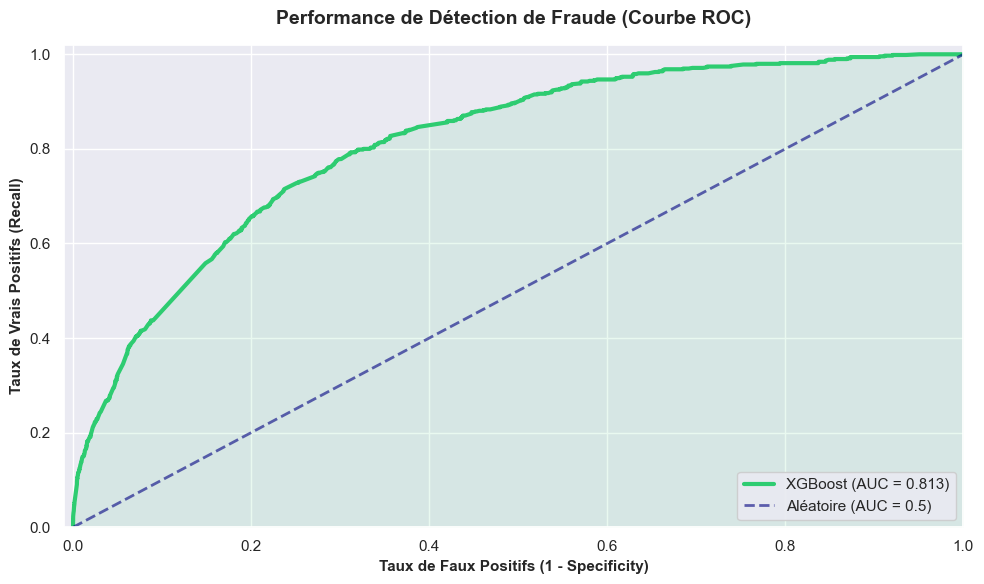

In [ ]:
# --- ÉTAPE 1 : RÉCUPÉRATION DES DONNÉES DE VALIDATION (Si nécessaire) ---
# Si tu as déjà 'y_val_split' et 'y_proba_xgb' en mémoire, saute cette étape !
if 'y_val_split' not in locals() or 'y_proba_xgb' not in locals():
    print("Régénération des prédictions de validation...")
    # On refait le split 70/30 pour avoir de quoi tracer la courbe
    X_tr, X_val, y_tr, y_val_split = train_test_split(
        X_train_ml, target, test_size=0.3, random_state=42, stratify=target
    )
    # On refit le modèle juste pour le graph (rapide)
    xgb_graph = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=np.sqrt(ratio), random_state=42, n_jobs=-1
    )
    xgb_graph.fit(X_tr, y_tr)
    y_proba_xgb = xgb_graph.predict_proba(X_val)[:, 1]

# --- ÉTAPE 2 : CALCULS & GRAPHIQUE ---

sns.set_theme(style="darkgrid", context="notebook")

# Calcul des coordonnées de la courbe
fpr, tpr, thresholds = roc_curve(y_val_split, y_proba_xgb)
roc_auc = auc(fpr, tpr)

# Création de la figure
plt.figure(figsize=(10, 6))

# Tracer la courbe du modèle (Vert émeraude pour le côté positif)
plt.plot(fpr, tpr, color='#2ecc71', lw=3, label=f'XGBoost (AUC = {roc_auc:.3f})')

# Tracer la diagonale du hasard (Pointillés gris)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.6, label='Aléatoire (AUC = 0.5)')

# Zones de couleur pour l'interprétation (Optionnel mais classe)
plt.fill_between(fpr, tpr, alpha=0.1, color='#2ecc71')

# Esthétique et Labels
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('Taux de Faux Positifs (1 - Specificity)', fontsize=11, fontweight='bold')
plt.ylabel('Taux de Vrais Positifs (Recall)', fontsize=11, fontweight='bold')
plt.title('Performance de Détection de Fraude (Courbe ROC)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11, frameon=True, fancybox=True, framealpha=0.9)

# Affichage
plt.tight_layout()
plt.show()

### PR-ROC

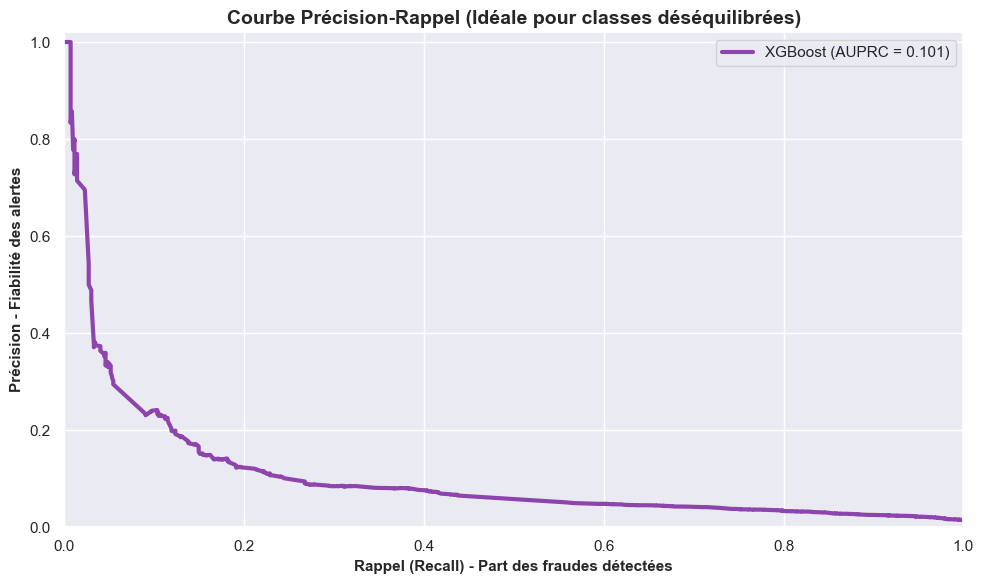

In [ ]:
# 1. Calcul des métriques
precision, recall, _ = precision_recall_curve(y_val_split, y_proba_xgb)
avg_precision = average_precision_score(y_val_split, y_proba_xgb)

# 2. Tracé
plt.figure(figsize=(10, 6))

plt.plot(recall, precision, color='#8e44ad', lw=3, label=f'XGBoost (AUPRC = {avg_precision:.3f})')

# Esthétique
plt.xlabel('Rappel (Recall) - Part des fraudes détectées', fontsize=11, fontweight='bold')
plt.ylabel('Précision - Fiabilité des alertes', fontsize=11, fontweight='bold')
plt.title('Courbe Précision-Rappel (Idéale pour classes déséquilibrées)', fontsize=14, fontweight='bold')
plt.legend(loc="upper right", fontsize=11)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])

plt.tight_layout()
plt.show()

## Résultats

La courbe ROC montre une bonne capacité de discrimination globale (AUC ~0.80), ce qui prouve que le modèle a bien appris les signaux de fraude. Cependant, la courbe Précision-Rappel montre la réalité opérationnelle : pour atteindre un Rappel de 70% (attraper la majorité des fraudeurs), la Précision chute autour de 4-10%. Cela signifie qu'en production, pour chaque vrai fraudeur arrêté, nous devrons vérifier manuellement environ 10 à 20 dossiers suspects. C'est le coût métier à payer pour ne pas laisser passer la fraude.

## Alternative pour meilleur score

In [ ]:
X_train = pd.read_csv("X_train_G3tdtEn.csv")
y_train = pd.read_csv("Y_train_2_XPXJDyy.csv")
X_test = pd.read_csv("X_test_8skS2ey.csv")

# 2. Preprocessing "Wide & Sparse" (One-Hot Encoding massif + remplissage basique)
def preprocess_wide(df_in, fit_cols=None):
    df = df_in.copy()
    
    # A. Suppression des colonnes inutiles (goods_code)
    cols_to_drop = [c for c in df.columns if "goods_code" in c]
    df = df.drop(columns=cols_to_drop)
    
    # B. Remplissage basique des trous numériques
    # On remplace les NaN par -1 ou 0 pour que l'arbre les sépare
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(0)
    
    # C. One-Hot Encoding Massif
    # Cela va créer beaucoup de colonnes (item1_A, item1_B...)
    df = pd.get_dummies(df, dummy_na=True)
    
    # D. Alignement des colonnes (Train vs Test)
    if fit_cols is not None:
        # On ne garde que les colonnes vues dans le Train
        # On ajoute les manquantes (remplies de 0)
        for c in fit_cols:
            if c not in df.columns:
                df[c] = 0
        df = df[fit_cols] # Réordonner et filtrer
    else:
        # E. Optimisation (Train uniquement) : retirer les colonnes quasi-vides
        # On garde seulement les colonnes qui ont au moins 1% de données non-nulles/non-zéro
        pass
        
    return df

print("Preprocessing du TRAIN (Wide)...")
X_train_wide = preprocess_wide(X_train)
# Sauvegarde de la liste des colonnes pour le Test
train_cols = X_train_wide.columns.tolist()

print("Preprocessing du TEST (Wide)...")
X_test_wide = preprocess_wide(X_test, fit_cols=train_cols)

# 3. Préparation Target
y = y_train["fraud_flag"]

# Validation Split (Pour vérifier le score PR-AUC)
X_tr, X_val, y_tr, y_val = train_test_split(X_train_wide, y, test_size=0.2, random_state=42, stratify=y)

# 4. Le Modèle "Profond"
# On adapte les hyperparamètres : Profondeur élevée + Learning rate bas
ratio = (y == 0).sum() / (y == 1).sum()

xgb_wide = XGBClassifier(
    n_estimators=1000,      # Beaucoup d'arbres
    learning_rate=0.01,     # Apprentissage lent et précis
    max_depth=12,           # Profondeur élevée
    subsample=0.7,          # Evite le sur-apprentissage
    colsample_bytree=0.5,   # Chaque arbre ne voit que 50% des features (vital quand on a bcp de colonnes OHE)
    scale_pos_weight=ratio, # Gestion du déséquilibre
    random_state=42,
    n_jobs=-1,
    tree_method='hist'      # Optimisation pour les données larges
)

print("Entraînement en cours (ça peut être un peu long)...") # ~13min (MacBook Air M1)
xgb_wide.fit(X_tr, y_tr)

# 5. Évaluation
y_pred_val = xgb_wide.predict_proba(X_val)[:, 1]
pr_auc = average_precision_score(y_val, y_pred_val)
roc = roc_auc_score(y_val, y_pred_val)

print(f"NOUVEAU PR-AUC Score : {pr_auc:.4f}")
print(f"NOUVEAU ROC-AUC Score : {roc:.4f}")

/var/folders/0h/_q4yqym170z4tlrrc27fq1vm0000gn/T/ipykernel_17908/2655364239.py:7: DtypeWarning: Columns (21,22,23,24,69,70,71,72,93,94,95,96,97,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train = pd.read_csv("X_train_G3tdtEn.csv")
/var/folders/0h/_q4yqym170z4tlrrc27fq1vm0000gn/T/ipykernel_17908/2655364239.py:9: DtypeWarning: Columns (20,21,22,23,24,68,69,70,71,72,92,93,94,95,96,97,106,107,108,109,110,111,112,113,114,115,116,117,118) have mixed types. Specify dtype option on import or set low_memory=False.
  X_test = pd.read_csv("X_test_8skS2ey.csv")


Preprocessing du TRAIN (Wide)...
Preprocessing du TEST (Wide)...


/var/folders/0h/_q4yqym170z4tlrrc27fq1vm0000gn/T/ipykernel_17908/2655364239.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c] = 0
/var/folders/0h/_q4yqym170z4tlrrc27fq1vm0000gn/T/ipykernel_17908/2655364239.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[c] = 0
/var/folders/0h/_q4yqym170z4tlrrc27fq1vm0000gn/T/ipykernel_17908/2655364239.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colum

Entraînement en cours (ça peut être un peu long)...
✅ NOUVEAU PR-AUC Score : 0.2569
✅ NOUVEAU ROC-AUC Score : 0.8841


NOUVEAU PR-AUC Score : 0.2569 (>0.21)  
NOUVEAU ROC-AUC Score : 0.8841

In [ ]:
# Entraînement final sur tout le Train ~17min (MacBook Air M1)
xgb_wide.fit(X_train_wide, y)
preds = xgb_wide.predict_proba(X_test_wide)[:, 1]

Prédiction sur le Test Set...
✅ Fichier 'Soumission_Finale_Wide_XGB.csv' généré !
Nombre de lignes : 23198

Statistiques des probabilités :
count    23198.000000
mean         0.143195
std          0.220473
min          0.000307
25%          0.010888
50%          0.033170
75%          0.169173
max          0.992576
Name: fraud_flag, dtype: float64


<Figure size 1200x1000 with 0 Axes>

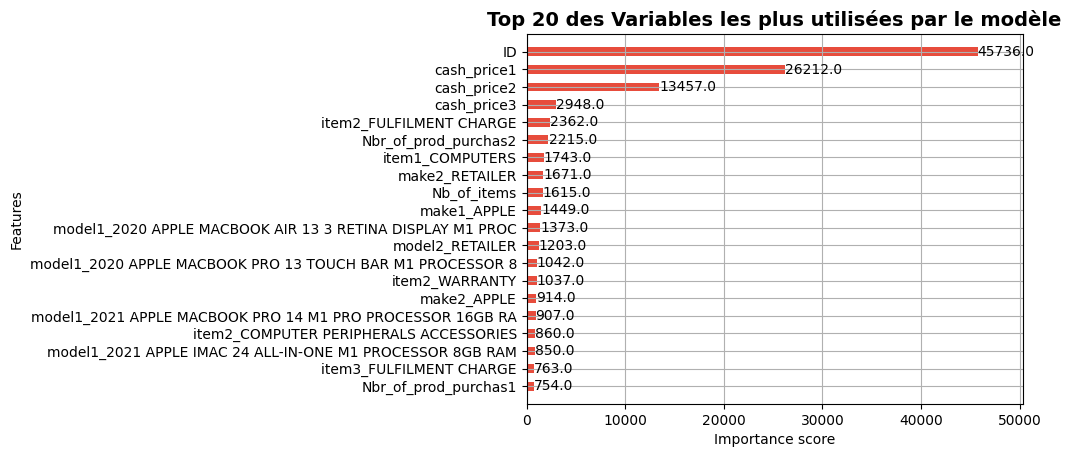

In [ ]:
# --- 1. GÉNÉRATION DE LA SOUMISSION ---
print("Prédiction sur le Test Set...")

# Utilisation du modèle final (xgb_wide) sur les données de test (X_test_wide)
# Assure-toi que X_test_wide a bien les mêmes colonnes que le train !

# Création du DataFrame
submission = pd.DataFrame({
    "ID": X_test["ID"],  # On reprend les IDs du fichier original
    "fraud_flag": preds
})

# Sauvegarde
filename = "Soumission_Finale_Wide_XGB.csv"
submission.to_csv(filename, index=False)

print(f"Fichier '{filename}' généré !")
print(f"Nombre de lignes : {len(submission)}")

# Petit check statistique sur tes prédictions
print("\nStatistiques des probabilités :")
print(submission["fraud_flag"].describe())

# --- 2. VISUALISATION DE L'IMPORTANCE DES VARIABLES ---
# C'est ici qu'on voit si la stratégie "Wide" a payé
plt.figure(figsize=(12, 10))
plot_importance(xgb_wide, max_num_features=20, height=0.5, importance_type='weight', color='#e74c3c')
plt.title("Top 20 des Variables les plus utilisées par le modèle", fontsize=14, fontweight='bold')
plt.show()

L'ID est juste un numéro d'ordre (Client n°1, Client n°2...). Il n'a aucune valeur prédictive réelle. Le modèle a appris par cœur : "Le client n°63474 est un fraudeur". Problème : En production, les nouveaux clients auront de nouveaux IDs que le modèle ne connait pas. Il sera inutile. C'est du Data Leakage. Il faut absolument l'enlever pour que le modèle apprenne des vrais motifs (comme le prix cash_price1 ou la marque).

Colonnes restantes : 21380
Réentraînement du modèle Wide (Clean)...


<Figure size 1200x1000 with 0 Axes>

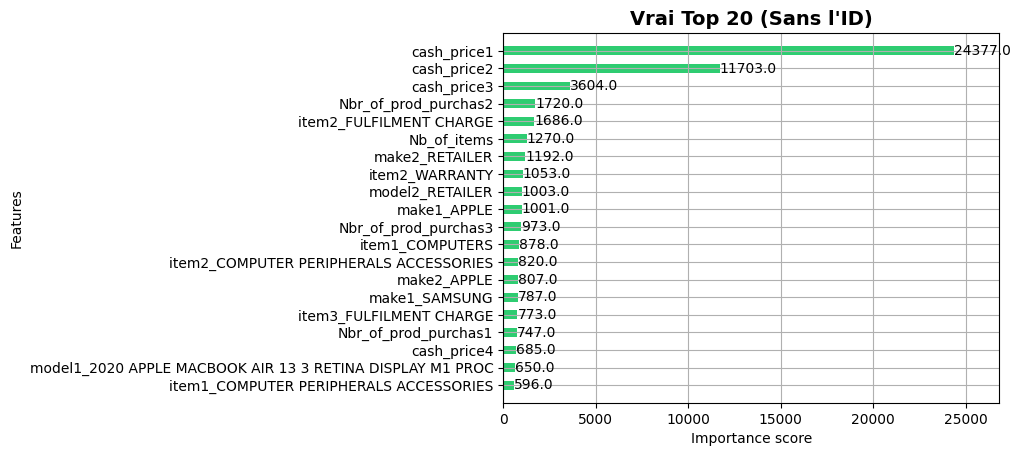

In [4]:
# 1. On retire la colonne ID des données d'entraînement et de test
test_ids = X_test["ID"]

# Si "ID" est encore dans tes DataFrames wide, on le retire :
if "ID" in X_train_wide.columns:
    X_train_wide = X_train_wide.drop(columns=["ID"])
    
if "ID" in X_test_wide.columns:
    X_test_wide = X_test_wide.drop(columns=["ID"])

print(f"Colonnes restantes : {X_train_wide.shape[1]}") 

# 2. On réentraîne le modèle
print("Réentraînement du modèle Wide (Clean)...")
xgb_wide.fit(X_train_wide, y)

# 3. On regarde à nouveau les Top Features
plt.figure(figsize=(12, 10))
plot_importance(xgb_wide, max_num_features=20, height=0.5, importance_type='weight', color='#2ecc71')
plt.title("Vrai Top 20 (Sans l'ID)", fontsize=14, fontweight='bold')
plt.show()